In [143]:
# Import libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings('ignore')


In [144]:
df=pd.read_csv('KNN_Practice_Dataset.csv')
df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Target
0,1.551992,-1.757423,-1.570917,0.236486,-1.332205,-2.093884,1
1,0.259055,2.131299,-2.582957,-0.193615,-1.076261,2.318128,1
2,0.111624,1.299046,-0.484089,0.519079,-0.651576,0.680482,2
3,-1.499083,1.648867,-0.185584,0.133872,1.860264,-0.434453,0
4,1.402466,-0.652082,-0.335631,-0.041671,-0.251467,0.161216,1


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  2500 non-null   float64
 1   Feature2  2500 non-null   float64
 2   Feature3  2500 non-null   float64
 3   Feature4  2500 non-null   float64
 4   Feature5  2500 non-null   float64
 5   Feature6  2500 non-null   float64
 6   Target    2500 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 136.8 KB


In [146]:
df.describe()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Target
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,0.363947,0.040900,-0.006434,0.011254,-0.320349,0.050085,0.999600
std,1.522921,1.520771,1.012831,0.979988,1.453886,1.648779,0.818699
min,-5.852777,-4.239744,-3.365296,-3.099159,-5.098003,-4.829650,0.000000
25%,-0.607923,-1.093697,-0.703372,-0.659061,-1.299488,-1.139820,0.000000
50%,0.519118,-0.083930,0.002260,-0.006723,-0.434330,-0.066858,1.000000
75%,1.406271,1.155435,0.681368,0.675401,0.596890,1.214972,2.000000
max,5.254429,5.072808,3.235470,3.418612,5.652185,6.269318,2.000000


In [147]:
df.duplicated().sum()

np.int64(0)

In [148]:
x=df.drop('Target',axis=1)
y=df[['Target']]
x.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6
0,1.551992,-1.757423,-1.570917,0.236486,-1.332205,-2.093884
1,0.259055,2.131299,-2.582957,-0.193615,-1.076261,2.318128
2,0.111624,1.299046,-0.484089,0.519079,-0.651576,0.680482
3,-1.499083,1.648867,-0.185584,0.133872,1.860264,-0.434453
4,1.402466,-0.652082,-0.335631,-0.041671,-0.251467,0.161216


In [149]:
y

,Target
0,1
1,1
2,2
3,0
4,1
...,...
2495,2
2496,1
2497,0
2498,0


<Axes: xlabel='Target', ylabel='count'>

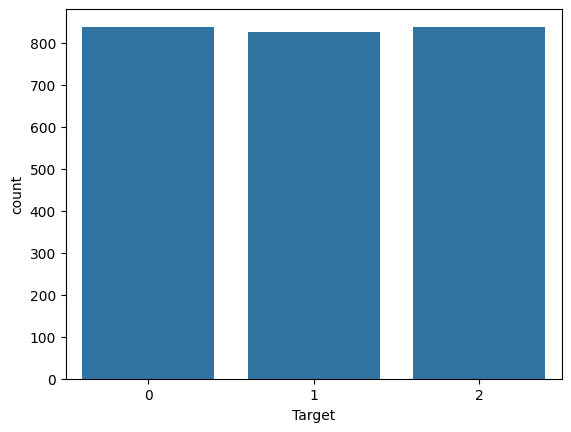

In [150]:
sns.countplot(x=y['Target'])

<Axes: >

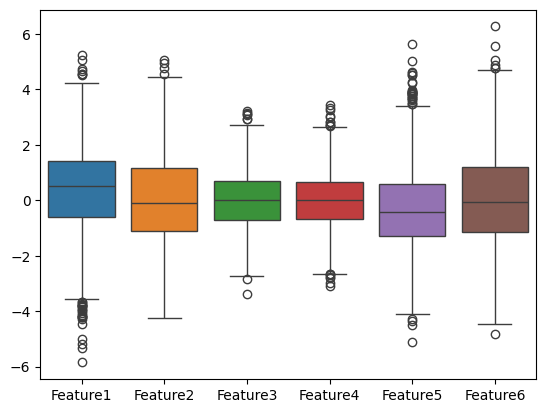

In [151]:
sns.boxplot(x)

In [152]:
for i in x:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lo=q1-1.5*iqr
    hi=q3+1.5*iqr
    x[i] = np.clip(x[i], lo, hi)


<Axes: >

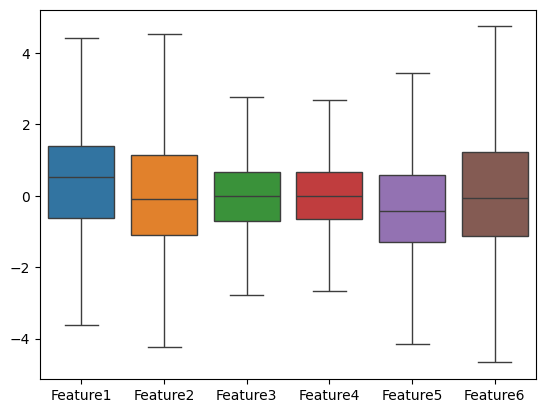

In [153]:
sns.boxplot(x)

In [154]:
x.columns

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6'], dtype='object')

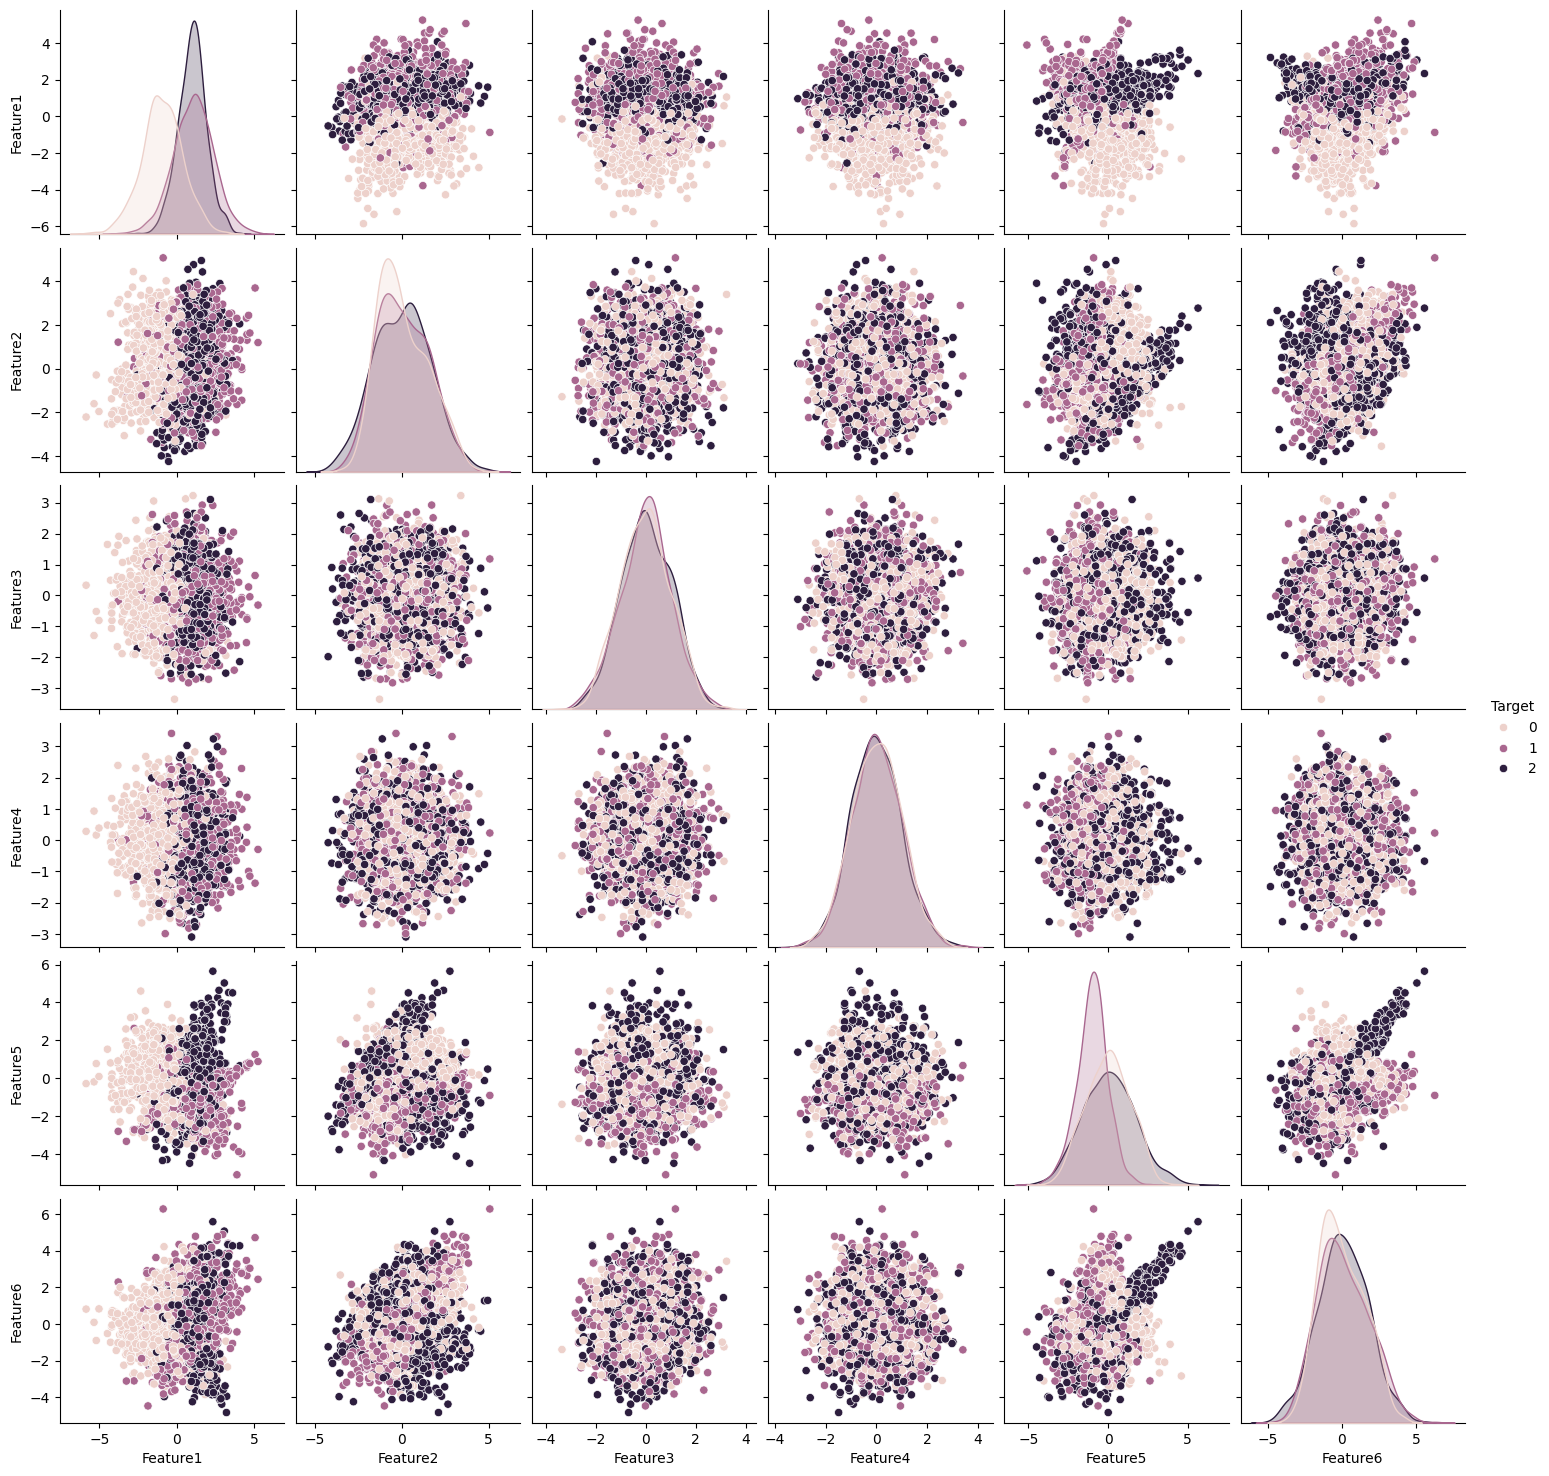

In [155]:
sns.pairplot(df,
             vars=['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6'],
             hue='Target')

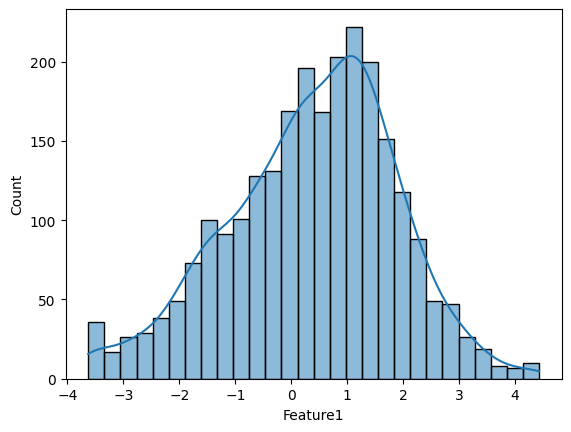

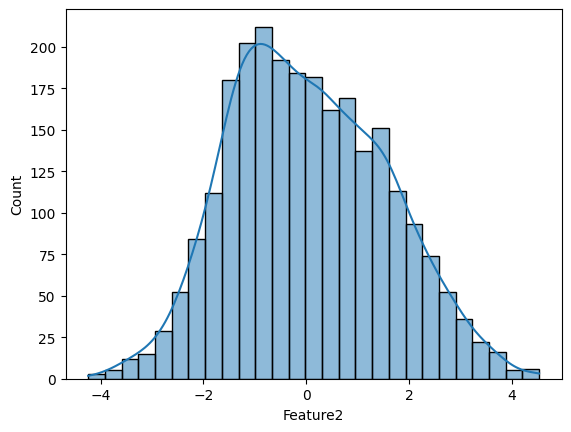

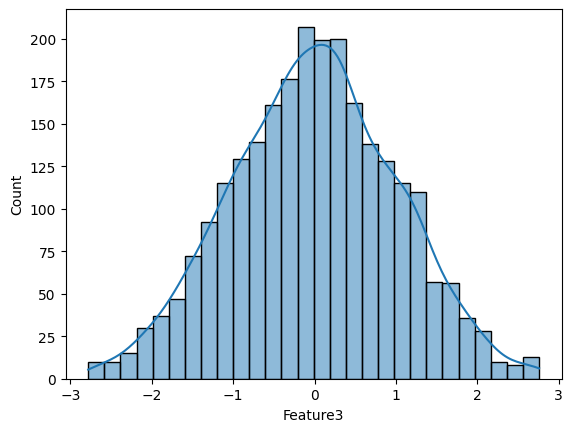

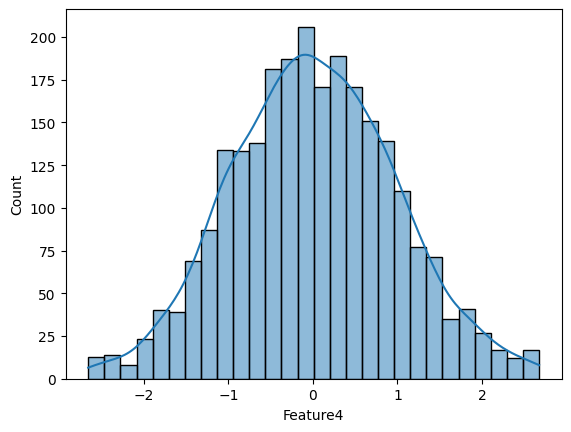

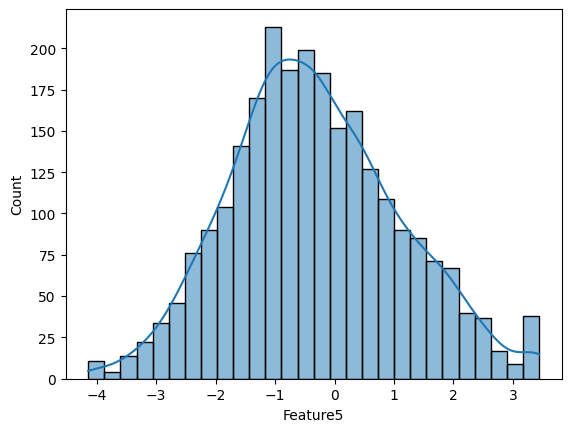

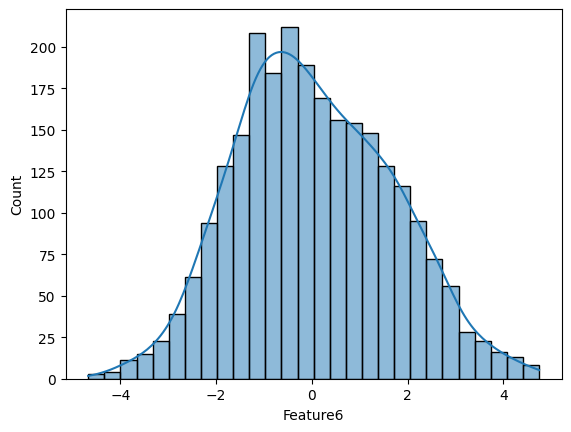

In [156]:
for i in x:
    sns.histplot(x[i],kde=True)
    plt.show()

In [157]:
x_cop=x.columns
x_cop

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6'], dtype='object')

In [158]:
from sklearn.preprocessing import StandardScaler
scal=StandardScaler()
x=scal.fit_transform(x)
x=pd.DataFrame(x,columns=x_cop)
x.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6
0,0.787167,-1.183596,-1.548933,0.231818,-0.702229,-1.302960
1,-0.072791,1.376522,-2.551218,-0.209350,-0.523589,1.379712
2,-0.170850,0.828613,-0.472578,0.521684,-0.227174,0.383961
3,-1.242164,1.058916,-0.176950,0.126564,1.526000,-0.293962
4,0.687714,-0.455901,-0.325550,-0.053497,0.052087,0.068227


In [159]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [160]:
from sklearn.neighbors import KNeighborsClassifier

model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [161]:
ypred=model.predict(x_test)
ypred

array([0, 1, 1, 1, 0, 2, 2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0,
       2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 1, 2, 2, 1, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 0, 1, 2, 1, 2, 0,
       1, 2, 1, 2, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 0,
       1, 0, 1, 2, 0, 0, 2, 1, 0, 0, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1, 2, 2,
       2, 0, 2, 1, 0, 1, 1, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 0, 0, 1, 0, 1,
       2, 2, 2, 1, 1, 1, 0, 2, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 2, 0, 2, 0,
       1, 1, 1, 2, 0, 2, 2, 2, 2, 1, 0, 1, 2, 0, 2, 1, 2, 1, 1, 0, 1, 1,
       2, 1, 2, 1, 2, 0, 0, 0, 0, 0, 2, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 0,
       1, 1, 2, 1, 2, 1, 0, 1, 1, 2, 2, 1, 0, 1, 0, 0, 2, 2, 1, 1, 2, 1,
       1, 2, 1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 2, 0, 2, 1, 1, 0, 1, 0, 2, 0, 0, 1, 1, 2, 0,
       0, 2, 1, 0, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 1, 0, 2, 2, 1, 0, 2, 1,
       1, 0, 2, 1, 0, 0, 2, 1, 1, 0, 0, 1, 2, 0, 0,

In [162]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index()
res

,actual,predicted
1447,0,0
1114,1,1
1064,1,1
2287,1,1
1537,0,0
...,...,...
427,2,2
105,0,0
2044,0,0
121,2,2


Accuracy: 0.8013333333333333
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       249
           1       0.75      0.79      0.77       242
           2       0.86      0.76      0.80       259

    accuracy                           0.80       750
   macro avg       0.80      0.80      0.80       750
weighted avg       0.80      0.80      0.80       750



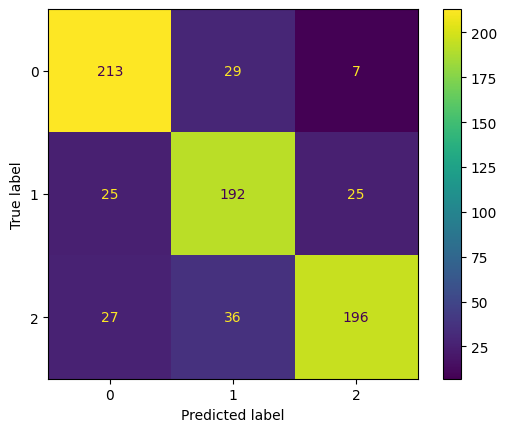

In [163]:
from sklearn.metrics import ConfusionMatrixDisplay
print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred))
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.show()